# HW 3: STFT, Features, and Regression (15 points)

For each markdown cell, add a cell (or cells) of code below. 
Reminders:
* This is an individual assignment. 
* If you use GenAI tools to assist you with your homework, remember to fill out the GenAI Usage Statement at the bottom of the notebook. Even if you use GenAI, you should not be directly copying the code.
* You may only use functions/packages we have discussed in class

Read in the following files from your "audio" folder.
- /audio/country.00000.wav
- /audio/hiphop.00000.wav
    
Ensure that amplitudes are normalized to between -1 and 1. 

In [166]:
import numpy as np 
import matplotlib.pyplot as plt
from scipy import signal
from numpy import fft
from scipy.io.wavfile import read
from IPython.display import Audio
from librosa import frames_to_time
from librosa.feature import zero_crossing_rate, spectral_centroid
import pandas as pd 
from sklearn import preprocessing
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split


In [167]:
fs, x = read('../audio/country.00000.wav')
fs1, x1 = read('../audio/hiphop.00000.wav')
x_norm = x/np.max(abs(x))
x1_norm = x1/np.max(abs(x1))

In [168]:
import math
def NextPowerOfTwo(number):
    return 2**(math.ceil(np.log2(number)))

## Part 1: STFT parameters and visualization (6 points)

#### Write your own STFT (3 points)

Write your own STFT function that will output a 2D matrix with shape (num_frames, num_bins), where each row contains the DFT of a single frame.

* Use a hop size equal to half the frame size (i.e., hop_size = frame_size // 2) so that frames overlap by 50%, and you should apply a hanning window to each frame (you may use `np.hanning()` for this.)

* The user should be able to vary the size of the frame (leave hop_size fixed at 50%).

*Note: You should use the built in numpy FFT function (instead of your DFT). This means you will have to work in powers of 2!*

In [169]:
# your code here
def my_stft(audio_input, frame_size, sampling_rate = 44100):
    
    # Define frame_length (should be power of two based on input frame_size)
    frame_length = NextPowerOfTwo(frame_size)

    # Define hop size is half the frame size
    hop_length = frame_length // 2

    # Define number of frames (m) we can extract with 50% overlap based on the total length of our signal
    # If the signal does not fit an integer number of frames, truncate
    n_mbins = int(audio_input.size / hop_length) - 1

    # Define total number of frequency bins
    n_kbins = frame_length // 2

    # Pre-allocate matrix for STFT. Remember it should be structured as [time_frames, frequency_bins]
    stft_matrix = np.zeros((n_mbins,n_kbins))

    # Define window
    window = np.hanning(frame_length)

    # Iterate through signal by frame
    for m in range(n_mbins):
        i = m*hop_length
        frame = audio_input[i:(i+frame_length)]
        frame_win = frame*window
        frame_fft = np.fft.fft(frame_win)
        for k in range(n_kbins):
            stft_matrix[m][k] = frame_fft[k]

    return stft_matrix


#### Apply your STFT function

Apply your STFT function to the audio files listed above (country and hiphop)

In [170]:
# your code here
country_stft = my_stft(x_norm, 1024, sampling_rate=fs)
hip_hop_stft = my_stft(x1_norm, 1024, sampling_rate=fs1)
country_stft, hip_hop_stft

/var/folders/88/n40k4jj52mlcqk5ftw8mhlsm0000gn/T/ipykernel_59914/1029307208.py:30: ComplexWarning: Casting complex values to real discards the imaginary part
  stft_matrix[m][k] = frame_fft[k]


(array([[-1.56546166e+00,  3.15706455e+00, -6.51318280e+00, ...,
         -2.20422830e-03, -6.48988623e-02,  3.96546538e-02],
        [-1.86352133e+00,  3.03958197e+00, -2.03571661e+00, ...,
         -1.03500744e-01,  1.43928005e-01, -1.64717359e-01],
        [-7.10886932e-01,  3.67532920e+00, -9.72458104e+00, ...,
          4.36023939e-02, -9.98588273e-02,  2.45726439e-01],
        ...,
        [ 1.76107165e+00,  1.89182283e+01, -5.25184499e+01, ...,
         -1.09404650e-01,  2.68426080e-01, -6.76433154e-01],
        [ 1.16885977e-01,  7.15264777e+00, -1.06869285e+01, ...,
         -3.86456508e-02,  3.13330757e-02, -7.45097489e-02],
        [-2.51948227e+00,  5.55154967e+00, -6.64033052e+00, ...,
          1.58210372e-01, -9.43371873e-03, -4.12983333e-01]]),
 array([[-1.52093387e+01,  8.37015720e+00, -6.63932111e-01, ...,
         -1.70646242e-04,  3.79584659e-05,  1.96845738e-04],
        [-6.90401956e+00,  3.54344408e+00,  3.91802640e-01, ...,
          4.52414234e-05,  2.06346608e

#### Write your own spectrogram function (3 points)

Write your own spectrogram function (using `plt.pcolormesh()`) called `plot_spectrogram()` that takes the complex-valued STFT output from your above function, and the sampling rate, and plots a magnitude spectrogram in decibels.

The axes should be properly labeled (time on x-axis, Frequency on y-axis).

*Note: audio processing workflows and dataframe logic in general in Python commonly use rows = time. However, several plotting functions like pcolormesh() annoyingly expect rows = frequency and columns = time. Therefore, we simply add a step to 'transpose' our 2d array or matrix in our code below.*


In [171]:
# your code here
def plot_spectrogram(stft_matrix, frame_size, sampling_rate):

    # Take magnitude and convert to decibels
    magnitude = np.abs(stft_matrix).T  # Transpose so rows = frequencies
    magnitude_db = 20 * np.log10(magnitude + 1e-6)  # avoid log(0)

    # Time and frequency axes
    num_frames = stft_matrix.shape[0]  # total number of frames
    hop_size = frame_size // 2  # recall it was 50% of the frame size
    duration = (num_frames * hop_size) / sampling_rate # find duration
    
    # Make a time axis by taking the total duration and dividing the timeline according to the number of frames:
    time_axis = np.linspace(0,duration,num_frames)
    # Ditto for frequency axis according to the number of bins
    freq_axis = np.linspace(0,sampling_rate / 2,hop_size)

    # Plot only up to Nyquist frequency by indexing your magnitude vector
    plt.pcolormesh(time_axis, freq_axis, magnitude_db)

Plot the spectrogram of the country and hiphop audio files

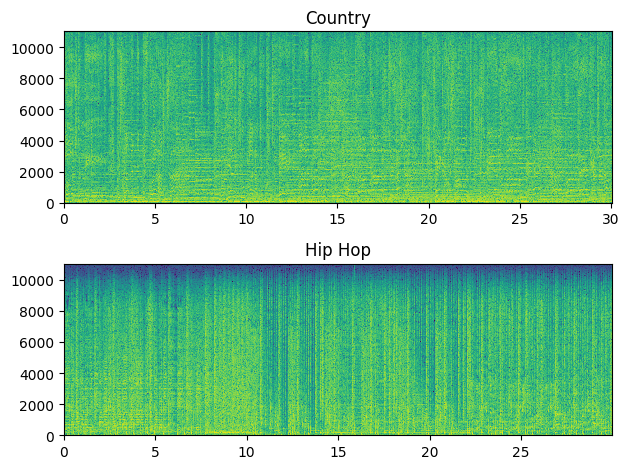

In [172]:
#plot_spectrogram(country_stft, 1024, fs1)
plt.subplot(2,1,2)
plot_spectrogram(hip_hop_stft, 1024, fs1)
plt.title('Hip Hop')
plt.subplot(2,1,1)
plot_spectrogram(country_stft, 1024, fs)
plt.title('Country')
plt.tight_layout()


## Part 2: Feature Extraction (4 points)

We will perform feature extraction and compare the two audio files above.

Extract the following features for each file (you may use librosa functions):
- RMSE
- Spectral Centroid
- Spectral Flux
- ZCR

For each feature:
- graph the results of each feature
- briefly describe what the feature might tell us perceptually
- briefly describe whether or not this might be a useful feature for classification (based on the graphs)

1 point for each correct feature calculation and associated explanation/reasoning

In [173]:
frame_length = 1024
hop_length = 512

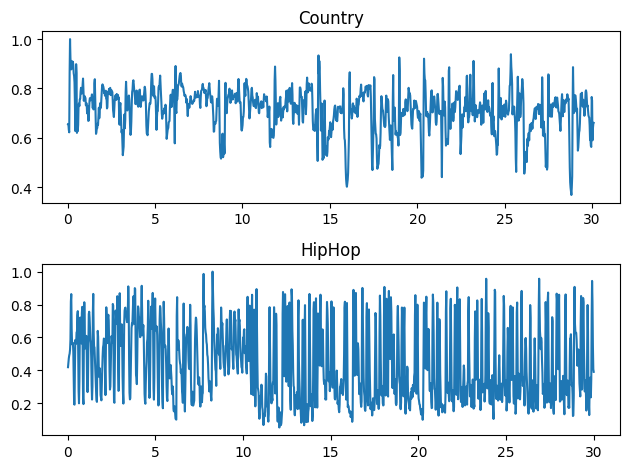

In [174]:
# RMSE for hiphop
energy = np.array([sum(abs(x_norm[i:i+frame_length])) for i in range(0, len(x_norm), hop_length)])
rmse_country = np.array([])
for i in range(0,len(x_norm),hop_length):
    rms_i_country = np.sqrt(np.mean(abs(x_norm[i:i+frame_length]**2)))
    rmse_country = np.append(rmse_country,rms_i_country)
# RMSE for country
energy1 = np.array([sum(abs(x1_norm[i:i+frame_length])) for i in range(0, len(x1_norm), hop_length)])
rmse_hiphop = np.array([])
for i in range(0,len(x1_norm),hop_length):
    rms_i_hiphop = np.sqrt(np.mean(abs(x1_norm[i:i+frame_length]**2)))
    rmse_hiphop = np.append(rmse_hiphop,rms_i_hiphop)
# plotting
frames = range(1,len(energy)+1)
t = frames_to_time(frames, sr=fs, hop_length = hop_length)
frames1 = range(1,len(energy1)+1)
t1 = frames_to_time(frames1, sr=fs1, hop_length = hop_length)

plt.subplot(2,1,1)
plt.plot(t,rmse_country/rmse_country.max())
plt.title('Country')
plt.subplot(2,1,2)
plt.plot(t1,rmse_hiphop/rmse_hiphop.max())
plt.title('HipHop')
plt.tight_layout()

Your RMSE explantion here!

The RMSE of a signal tells us the energy of the signal over a period of time. If we look at the above graph, we see that since the country audio has less fluctuations it may have less change in dynamics over time as compared to the Hiphop audio.

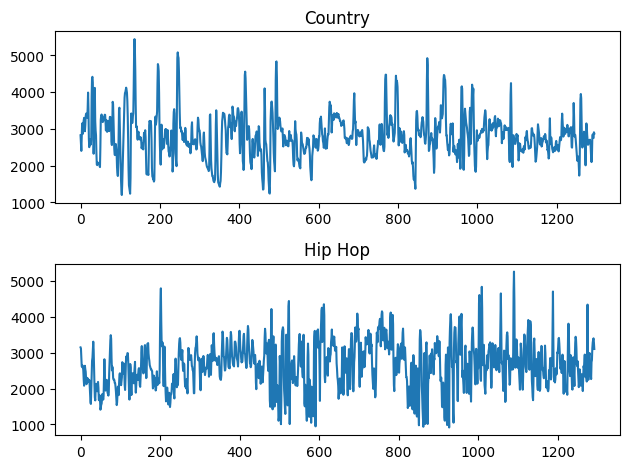

In [175]:
# Spectral Centroid for hiphop
country_sc = spectral_centroid(y=x_norm.astype(float), sr=fs)
# Spectral Centroid for country
hip_hop_sc = spectral_centroid(y=x1_norm.astype(float), sr=fs1)

frames = range(1,len(energy)+1)
t = frames_to_time(frames, sr=fs, hop_length = hop_length)
frames1 = range(1,len(energy1)+1)
t1 = frames_to_time(frames1, sr=fs1, hop_length = hop_length)

# plotting
plt.subplot(2,1,2)
plt.plot(hip_hop_sc[0])
plt.title('Hip Hop')
plt.subplot(2,1,1)
plt.plot(country_sc[0])
plt.title('Country')
plt.tight_layout()

Your centroid explanation here!

The spectral centroid describes the 'gravitational center' of the spectral energy. Perceptually it tells us the brightness or the nasality of a sound. Has we see that the country audio has more peaks, this means that it has a higher spectral centroid as compared to the hiphop audio. This tells us that the country audio contains more energy in the higher frequencies.

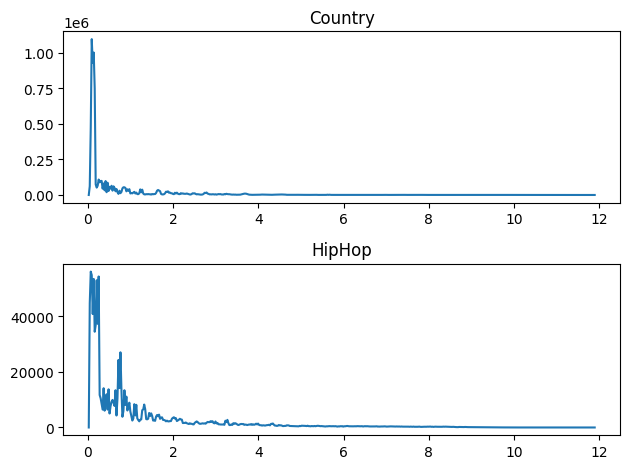

In [176]:
# spectral flux for hiphop
magnitude = np.abs(country_stft)
diff = np.diff(magnitude)
country_flux = np.sum(diff**2, axis=0)
country_flux = np.concatenate(([0], country_flux))
frames = range(1,len(country_flux)+1)
country_t = frames_to_time(frames,sr=fs,hop_length=hop_length)
# spectral flux for country
magnitude1 = np.abs(hip_hop_stft)
diff1 = np.diff(magnitude1)
hip_hop_flux = np.sum(diff1**2, axis=0)
hip_hop_flux = np.concatenate(([0],hip_hop_flux))
frames1 = range(1,len(hip_hop_flux)+1)
hip_hop_t = frames_to_time(frames1,sr=fs1,hop_length=hop_length)
# plotting
plt.subplot(2,1,1)
plt.plot(country_t,country_flux)
plt.title('Country')
plt.subplot(2,1,2)
plt.plot(hip_hop_t,hip_hop_flux)
plt.title('HipHop')
plt.tight_layout()

Your spectral flux explanation here!

Spectral Flux, tells us by how much the spectrum of a signal changes over time. We see that Hiphop has a more fluctuation hence telling us that it more changes in spectrum due to it having more percussive elements.

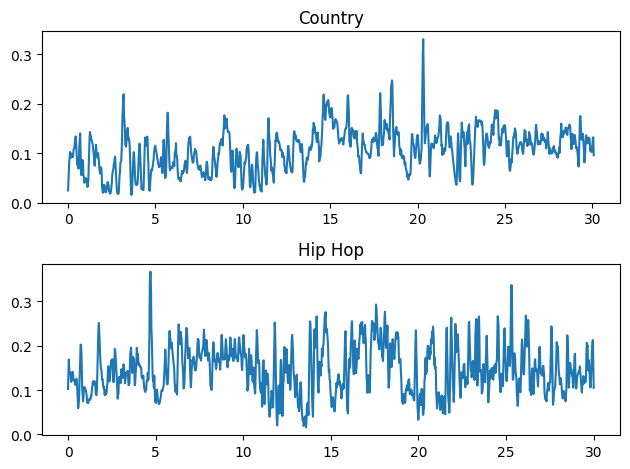

In [177]:
# ZCR for hiphop
country_zcr = zero_crossing_rate(x_norm.astype(float), hop_length=hop_length)
# ZCR for country
hiphop_zcr = zero_crossing_rate(x1_norm.astype(float), hop_length=hop_length)
# plotting
ax1 = np.linspace(0,len(x_norm)/fs,len(country_zcr[0]))
ax2 = np.linspace(0,len(x1_norm)/fs1,len(hiphop_zcr[0]))

plt.subplot(2,1,2)
plt.plot(ax2,hiphop_zcr[0])
plt.title('Hip Hop')
plt.subplot(2,1,1)
plt.plot(ax1,country_zcr[0])
plt.title('Country')
plt.tight_layout()

Your ZCR explanation here!

ZCR tells us how many frequently teh signal we are analysing changes signs. We can see that since HipHop has more fluctutaions there is a greater change in sign of the signal caused due to the presence of percussive elements in the audio.

## Part 3: Binomial Logistic Regression (5 points)

Like in activity 7, you will build a binomial classifier with logistic regression. You will use the GTZAN genre dataset 'features_30_sec.csv' this time to classify hiphop vs country music.

### Explore the data and select your features (3 points)

Use graphing and correlation techniques to determine 5 features you will use for your classification.

You must at a minimum create 1 bar graph and 1 box plot in addition to computing the correlation between the features you select.

Construct your Pandas dataframe for your chosen features. Remember you may want to do some scaling and normalization.

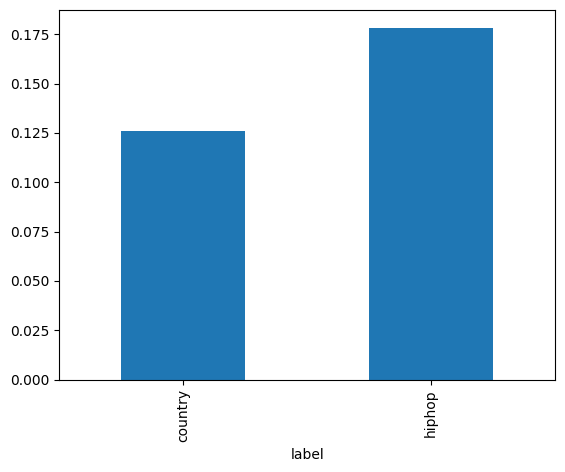

<Figure size 640x480 with 0 Axes>

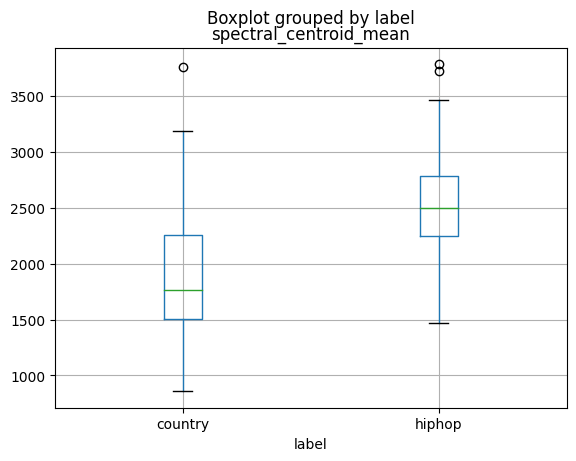

,rms_mean,rms_var,spectral_centroid_mean,spectral_centroid_var,zero_crossing_rate_mean
0,1.591235,-0.741591,0.957335,-0.546000,0.345604
1,1.295284,-0.792036,1.185979,-1.180150,0.939295
2,-0.092235,-0.577654,0.160200,-0.067667,-0.645985
3,0.862928,-0.505125,-0.059203,-0.004325,0.206346
4,0.947803,-0.722391,1.231494,-0.951759,0.854450


In [178]:
data = pd.read_csv('../Datasets/features_30_sec.csv')
genres = ['hiphop', 'country']
data = data[data['label'].isin(genres)]
features = ['rms_mean', 'rms_var', 'spectral_centroid_mean', 'spectral_centroid_var', 'zero_crossing_rate_mean']
data_features = data[features]
data_features.corr()

grouped = data.groupby('label').mean(numeric_only = True)
genre_rms = data.groupby('label')['rms_mean'].mean()
genre_rms.plot.bar('RMS mean by gere')
plt.figure()
data.boxplot(column='spectral_centroid_mean', by='label')
plt.show()


scaler = preprocessing.StandardScaler()
scaled_data = scaler.fit_transform(data_features)
data_features = pd.DataFrame(scaled_data, columns=features)
data_features.head()


### Train/Test Split

Use sklearn to split your data into testing and training sets. Remember you will need to define your categories, predictors, and test size. Use 30% test size.

In [179]:
predictors = data_features
data['label'] = pd.get_dummies(data['label'],drop_first=True)
categories = data['label']

pred_train, pred_test, cat_train, cat_test = train_test_split(predictors, categories, test_size = .3, random_state=25)

### Train the Model and Evaluate (2 points)

Train the model using logistic regression.

Calculate the confusion matrix (and view as a data frame). Calculate the accuracy, precision, recall, and F1 scores.

Explain what the confusion matrix and accuracy tell us about your model.

In [180]:
model = LogisticRegression(solver='lbfgs')
model.fit(pred_train, cat_train)
predictions = model.predict(pred_test)

from sklearn.metrics import confusion_matrix
cm = confusion_matrix(cat_test, predictions)
pd.DataFrame(cm, columns=['Country','Hiphop'], index=['Predicts_country','Predicts_hiphop'])

accuracy = ((26 + 24) / (26 + 24 + 7 + 3))
precision = 24 / (24 + 7)
recall = 24 / (24 + 3)
f1_score = 2 * (precision * recall) / (precision + recall)
accuracy, precision, recall, f1_score

(0.8333333333333334,
 0.7741935483870968,
 0.8888888888888888,
 0.8275862068965517)

Your model interpretation here!

The confusion matrix helps us analyising our model by telling us how accurate the model is. It gives us truth postives and truth negative which are values that are correctly predicted for each category we are predciting and false positives and false negetives that tells us errors caused by our model. The accuracy tells us how often or the likliness of our model to get a prediction right.

GenAI Usage Statement:

- Tool used and date of access
- The input (prompt) you provided
- A copy of the output
- A description of how you used or edited the AI-generated content